<a href="https://colab.research.google.com/github/gandhias-a11y/colab/blob/main/semester_project_0.5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semester Project: Project Nine from *Python Machine Learning Workbook for Beginners*

Textbook link: https://homes.luddy.indiana.edu/classes/spring2026/csci/a310-dgerman/protected/fall2022/resources/sem01.pdf

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPool2D
from tensorflow.keras.models import Model

In [21]:
import numpy as np

def load_idx3_ubyte_images(filepath):
    with open(filepath, 'rb') as f:
        # Read magic number (discarded)
        magic_number = int.from_bytes(f.read(4), 'big')
        # Read number of images
        num_images = int.from_bytes(f.read(4), 'big')
        # Read number of rows
        num_rows = int.from_bytes(f.read(4), 'big')
        # Read number of columns
        num_cols = int.from_bytes(f.read(4), 'big')

        # Read the image data and reshape it
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, num_rows, num_cols)

    return images

# New function for labels
def load_idx1_ubyte_labels(filepath):
    with open(filepath, 'rb') as f:
        # Read magic number (discarded)
        magic_number = int.from_bytes(f.read(4), 'big')
        # Read number of items (labels)
        num_items = int.from_bytes(f.read(4), 'big')

        # Read the label data
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        # Labels are 1-dimensional
        labels = labels.reshape(num_items)

    return labels

training_images = load_idx3_ubyte_images('emnist-letters-train-images-idx3-ubyte')
training_labels = load_idx1_ubyte_labels('emnist-letters-train-labels-idx1-ubyte')
test_images = load_idx3_ubyte_images('emnist-letters-test-images-idx3-ubyte')
test_labels = load_idx1_ubyte_labels('emnist-letters-test-labels-idx1-ubyte')

In [22]:
print(training_images.shape)
print(test_images.shape)
print(training_labels.shape)
print(test_labels.shape)

(124800, 28, 28)
(20800, 28, 28)
(124800,)
(20800,)


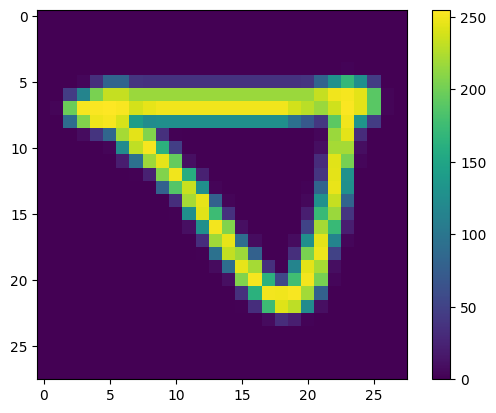

In [23]:
plt.figure()
plt.imshow(test_images[3000])
plt.colorbar()
plt.grid(False)
plt.show()

In [24]:
print(test_labels[3000])

4


In [25]:
np.unique(test_labels)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26], dtype=uint8)

In [26]:
training_images = np.expand_dims(training_images, -1)
test_images = np.expand_dims(test_images, -1)
print(training_images.shape)

(124800, 28, 28, 1)


In [27]:
output_classes = len(set(training_labels))